# Decision Tree

決策樹在訓練過程中會從最後上方的樹根開始將資料的特徵將資料分割到不同邊<br>
分割的原則是：這樣的分割要能得到最大的資訊增益(Information gain, 簡稱IG)。

由於我們希望獲得的資訊量要最大，因此經由分割後的資訊量要越小越好。

常見的資訊量有兩種：熵(Entropy) 以及 Gini不純度(Gini Impurity)




## 載入Iris資料集

In [90]:
%matplotlib inline
from sklearn import datasets
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os,sys
sys.path.append(os.path.abspath('./')) #for import common.utility
from utility import plot_confusion_matrix,plot_decision_regions,testcase_report

## 只用2個特徵進行分類
'sepal length (cm)', 'petal length (cm)'

In [91]:
iris = datasets.load_iris()
x = pd.DataFrame(iris['data'], columns=iris['feature_names'])
print("target_names: "+str(iris['target_names']))
y = pd.DataFrame(iris['target'], columns=['target'])
iris_data = pd.concat([x,y], axis=1)
#iris_data = iris_data[['sepal length (cm)','petal length (cm)','target']]
#只取 target 0,2
iris_data = iris_data[iris_data['target'].isin([1,2])]
print(iris_data.shape)

target_names: ['setosa' 'versicolor' 'virginica']
(100, 5)


In [92]:
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

## 將資料的70%拿出來train，剩下的30％用來檢測train的好壞
#### 透過 stratify 穩定資料切分時各類別的比例

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    iris_data.drop(columns = 'target'),
    iris_data['target'],
    test_size=0.3,
    random_state=1,
    stratify=iris_data['target']
)

# Decision Tree 不需要做特徵標準化

In [94]:
# from sklearn.preprocessing import StandardScaler

# sc = StandardScaler()
# sc.fit(X_train)
# X_train_std = sc.transform(X_train)
# X_test_std = sc.transform(X_test)

## DecisionTreeClassifier 參數
    criterion: entropy, gini impurity
    max_depth : 主要是可以防止樹長得過高造成overfit
    max_features: 最多只能挑K種feature去分類
    min_samples_leaf: leaf node最小sample數

#### 現在控制 decision tree 複雜度時，不只看 max_depth，也常一起搭配 min_samples_leaf、min_samples_split、ccp_alpha，避免模型把訓練資料背起來，變成一棵很有自信但其實很脆弱的樹。

#### 現代訓練可再增加：

    min_samples_split: 
    max_leaf_nodes: 
    ccp_alpha: 
    

In [99]:
from sklearn.tree import DecisionTreeClassifier

### use entropy as a criterion

In [100]:
clf = DecisionTreeClassifier(criterion = 'entropy', max_depth=3, random_state=0) #max_depth=1,3,12

### class sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, min_impurity_split=None, class_weight=None, presort='deprecated', ccp_alpha=0.0)

In [101]:
clf.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## 計算正確率

In [102]:
print('training score:',clf.score(X_train,y_train))
print('test score:',clf.score(X_test,y_test))

training score: 0.9142857142857143
test score: 0.9333333333333333


#### **決策樹很容易因資料切分不同而結果波動，所以更穩的做法通常是：**

    stratify=y 的 train/test split
    再搭配 cross_validate 或 cross_val_score
    classification task 最少補上 precision / recall / f1

In [103]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

cv_result = cross_validate(
    clf,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True
)

print("CV train accuracy:", cv_result['train_accuracy'].mean())
print("CV valid accuracy:", cv_result['test_accuracy'].mean())
print("CV valid f1_macro:", cv_result['test_f1_macro'].mean())

CV train accuracy: 0.9607142857142857
CV valid accuracy: 0.8857142857142856
CV valid f1_macro: 0.8848260073260074


In [104]:
clf.predict(X_test)

array([2, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1, 1, 1,
       1, 2, 2, 1, 1, 2, 2, 1])

In [105]:
y_test.values

array([2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 1, 2, 1, 1, 1, 1,
       1, 2, 2, 1, 1, 2, 2, 1])

### training Report

In [106]:
report=testcase_report(iris_data,clf,X_train,X_train,y_train)
report[0]

accuracy: 0.9142857142857143
error_index : [28 37 40 47 49 56]
miss classification : [1 1 1 1 1 1]
number of errors :6/70
error data index: Index([138, 149, 119, 123, 133, 127], dtype='int64')


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,pred
138,6.0,3.0,4.8,1.8,2,1
149,5.9,3.0,5.1,1.8,2,1
119,6.0,2.2,5.0,1.5,2,1
123,6.3,2.7,4.9,1.8,2,1
133,6.3,2.8,5.1,1.5,2,1
127,6.1,3.0,4.9,1.8,2,1


###  test Report

In [107]:
report=testcase_report(iris_data,clf,X_test,X_test,y_test)
report[0]

accuracy: 0.9333333333333333
error_index : [ 6 10]
miss classification : [1 1]
number of errors :2/30
error data index: Index([126, 106], dtype='int64')


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,pred
126,6.2,2.8,4.8,1.8,2,1
106,4.9,2.5,4.5,1.7,2,1


## 樹視覺化

scikit-learn中决策树的可视化一般需要安装graphviz。主要包括graphviz的安装和python的graphviz插件的安装。  
(可省略)安装graphviz。下載windows GraphViz's 工具： https://graphviz.gitlab.io/_pages/Download/Download_windows.html  
安装python插件graphviz： conda install graphviz  
安装python插件pydotplus。 conda install pydotplus  
这样环境就搭好了，有时候python会很笨，仍然找不到graphviz，这时，可以在代码里面加入这一行：  
os.environ["PATH"] += os.pathsep + 'C:/Program Files (x86)/Graphviz2.38/bin/'  
Open "command or conda prompt" and run:  
conda update conda  
conda update anaconda  


### Installation
**brew install graphviz**  
**uv add graphviz**
　　　　

### 方法 0：以 sklearn 官方提供的 plot_tree 進行繪圖（可作為nb主要展示方式）

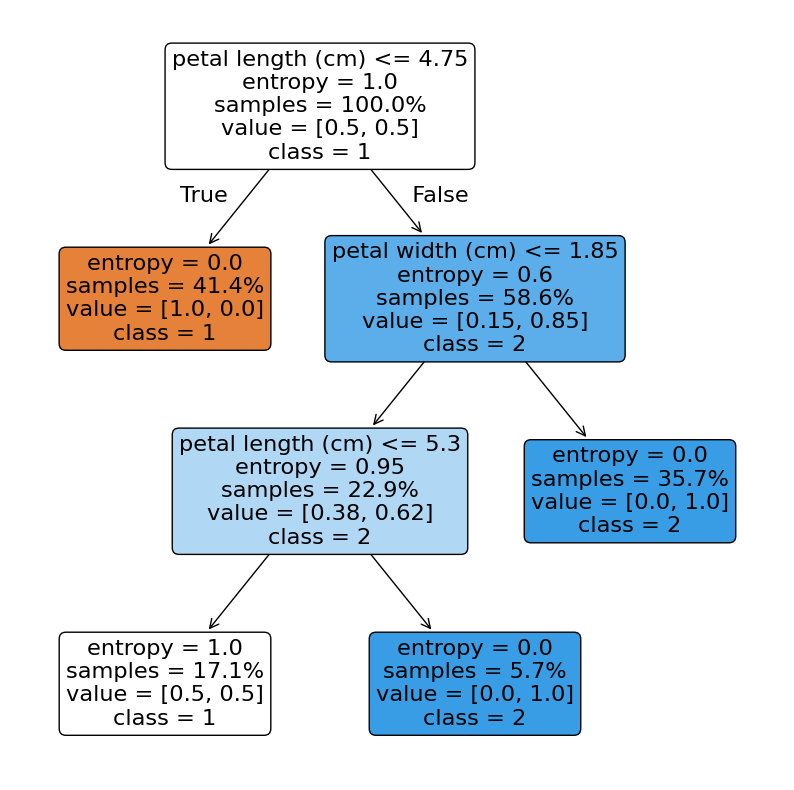

In [112]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
tree.plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=[str(c) for c in clf.classes_],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2
)
plt.show()

### 方法 1：以 graphviz 生成 iris.pdf 的決策樹圖（補充）
仍可保留，匯出 PDF 很方便  
樹很大時可讀性常比 matplotlib 更好  

In [41]:
from sklearn.tree import export_graphviz
from sklearn import tree
import os
#os.environ['PATH'] = os.environ['PATH'] + (';c:\\Program Files (x86)\\Graphviz2.38\\bin\\')

In [42]:
from graphviz import Source

dot_data = tree.export_graphviz(clf, out_file=None)
graph = Source(dot_data)

if not os.path.exists("output"):
    os.mkdir("output")
# 
graph.render("output/iris", format="pdf", cleanup=True)

'output/iris.pdf'

#### 同樣的方法微調

In [ ]:
# from pathlib import Path
# from sklearn.tree import export_graphviz
# from graphviz import Source

# output_dir = Path("output")
# output_dir.mkdir(exist_ok=True)

# dot_data = export_graphviz(clf, out_file=None)
# graph = Source(dot_data)
# graph.render(output_dir / "iris", format="pdf", cleanup=True)

### ~~方法1：使用 pydotplus 直接生成 iris.pdf~~

#### pydotplus is outdated
```python
# import pydotplus
# dot_data=tree.export_graphviz(clf,out_file=None)
# graph=pydotplus.graph_from_dot_data(dot_data)
# if not os.path.exists('output'):
#     os.mkdir('output')
# graph.write_pdf('output/iris.pdf')
```

### 方法2：直接在 jupyter notebook 中生成

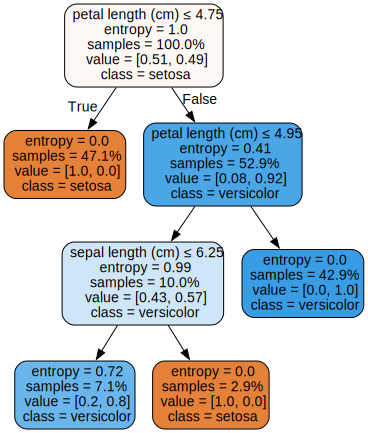

In [51]:
from sklearn import tree
from graphviz import Source

dot_data = tree.export_graphviz(
    clf,
    out_file=None,
    feature_names=iris['feature_names'],
    class_names=iris.target_names,
    filled=True, # 填色區分類別
    rounded=True, # 圓角
    special_characters=True,
    proportion=True,  # 顯示比例（如 samples 和 value 會改以從數字換成比例顯示）
    precision=2       # 小數點控制
)

graph = Source(dot_data)
graph

#### pydotplus is outdated

```python
# from IPython.display import Image  
# # 將 Decisson Tree Classifier 放入
# dot_data = tree.export_graphviz(clf, out_file=None,
#                          feature_names=iris['feature_names'],  
#                          class_names=iris.target_names,
#                          filled=True, rounded=True,  
#                          special_characters=True)   
# graph = pydotplus.graph_from_dot_data(dot_data)  
# Image(graph.create_png())  
```

## Return the feature importances.

The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It

In [52]:
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

樹模型的 impurity-based feature importance 不是萬能，它可能偏好高基數或連續型特徵，因此不能把它當成絕對真理。

    feature_importances_：快速看
    permutation_importance：較適合當驗證補充

兩者差很多時，要懷疑特徵相關性、資料量或模型穩定度
才不會變成「模型說它重要，所以它就重要」——那是樹在講話，不一定是事實。

In [53]:
clf.feature_importances_

array([0.04954031, 0.        , 0.95045969, 0.        ])

In [113]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    clf, X_test, y_test,
    n_repeats=30,
    random_state=0
)

pd.Series(
    perm_result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

petal length (cm)    0.411111
petal width (cm)     0.008889
sepal length (cm)    0.000000
sepal width (cm)     0.000000
dtype: float64

### use gini index as a criterion

In [54]:
clf_2 = DecisionTreeClassifier(criterion = 'gini', random_state=0 ,max_depth=3)

In [55]:
X_train.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
117,7.7,3.8,6.7,2.2
149,5.9,3.0,5.1,1.8
104,6.5,3.0,5.8,2.2
145,6.7,3.0,5.2,2.3
138,6.0,3.0,4.8,1.8


In [56]:
clf_2.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

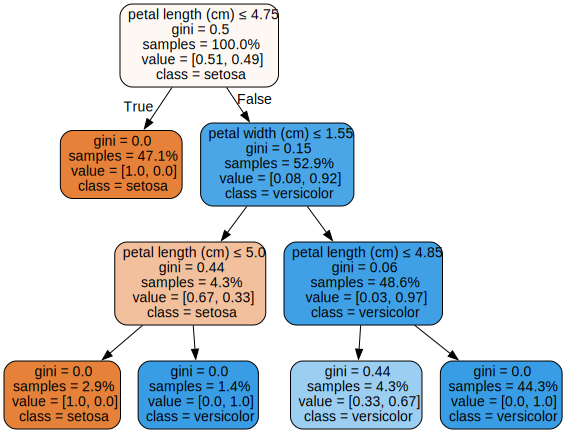

In [59]:
dot_data_2 = tree.export_graphviz(
    clf_2,
    out_file=None,
    feature_names=iris['feature_names'],
    class_names=iris.target_names,
    filled=True, # 填色區分類別
    rounded=True, # 圓角
    special_characters=True,
    proportion=True,  # 顯示比例（如 samples 和 value 會改以從數字換成比例顯示）
    precision=2       # 小數點控制
)

graph = Source(dot_data_2)
graph

#### pydotplus is outdated
```python
# from IPython.display import Image  
# #將 Decisson Tree Classifier 放入
# dot_data = tree.export_graphviz(clf_2, out_file=None,
#                          feature_names=iris['feature_names'],  
#                          class_names=iris.target_names,
#                          filled=True, rounded=True,  
#                          special_characters=True)   
# graph = pydotplus.graph_from_dot_data(dot_data)  
# Image(graph.create_png())  
```

# 只挑2個特徵進行分類
petal width (cm)','petal length (cm)

In [64]:
iris = datasets.load_iris()
x = pd.DataFrame(iris['data'], columns=iris['feature_names'])
print("target_names: "+str(iris['target_names']))
y = pd.DataFrame(iris['target'], columns=['target'])
iris_data = pd.concat([x,y], axis=1)
iris_data = iris_data[['petal width (cm)','petal length (cm)','target']]
iris_data.head(3)

target_names: ['setosa' 'versicolor' 'virginica']


,petal width (cm),petal length (cm),target
0,0.2,1.4,0
1,0.2,1.4,0
2,0.2,1.3,0


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    iris_data[['petal width (cm)','petal length (cm)']], iris_data['target'], test_size=0.3, random_state=0)

In [66]:
from sklearn.tree import DecisionTreeClassifier
clf_3 = DecisionTreeClassifier(criterion = 'entropy', max_depth=3, random_state=0)
clf_3.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [116]:
# 建議下面兩個參數可以這樣寫，這樣最穩，因為它永遠跟當下模型實際訓練資料一致。

feature_names=X_train.columns
class_names=[str(c) for c in clf.classes_]

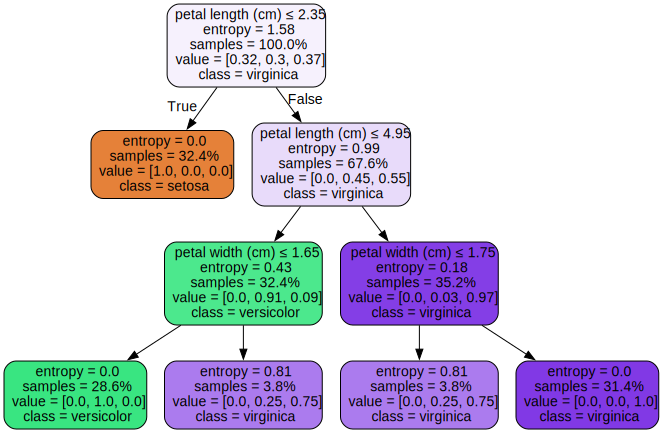

In [67]:
dot_data_3 = tree.export_graphviz(
    clf_3,
    out_file=None,
    feature_names=['petal width (cm)','petal length (cm)'],
    class_names=iris.target_names,
    filled=True, # 填色區分類別
    rounded=True, # 圓角
    special_characters=True,
    proportion=True,  # 顯示比例（如 samples 和 value 會改以從數字換成比例顯示）
    precision=2       # 小數點控制
)

graph = Source(dot_data_3)
graph

#### pydotplus is outdated
```python
# from IPython.display import Image  
# #將 Decisson Tree Classifier 放入
# dot_data = tree.export_graphviz(clf_3, out_file=None,
#                          feature_names=['petal width (cm)','petal length (cm)'],  
#                          class_names=iris.target_names,
#                          filled=True, rounded=True,  
#                          special_characters=True)   
# graph = pydotplus.graph_from_dot_data(dot_data)  
# Image(graph.create_png())  
```

## 視覺化決策樹的決策邊界
這種圖主要適合 2 個特徵的展示，若實際模型使用更多特徵，就不能只靠這張圖理解模型全貌。

/Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/wuyichan/IMLP-464/Unit05_2/utility.py:79: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


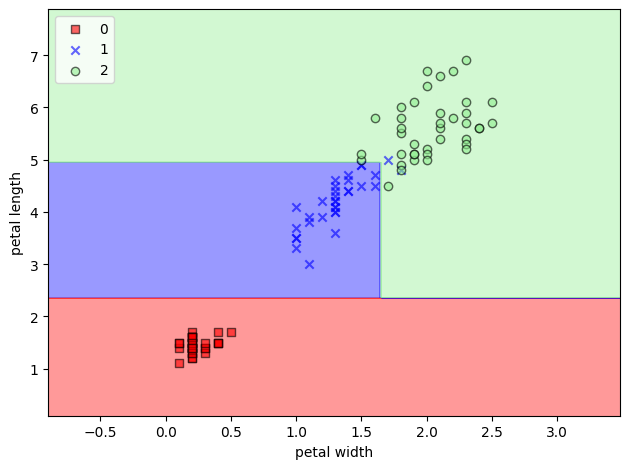

In [70]:
plot_decision_regions(X_train.values, y_train, classifier=clf_3)
plt.xlabel('petal width')
plt.ylabel('petal length')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Random Forest 隨機森林分類器

* Step1. 建立特徵X，與目標y
* Step2. 將資料區分成訓練集與測試集，可自行設定區分的百分比
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)
* Step3. 選擇隨機森林分類器，內容可決定決策數的棵樹、剪枝葉等等，以提升模型的效率及避免過度配適。
rfc=RandomForestClassifier(n_estimators=100,n_jobs = -1,random_state =50, min_samples_leaf = 10)
* Step4. 用建立好的模型來預測資料rfc.predict(X_test)
* Step5. 檢驗模型的正確率
rfc.score(X_test,y_test)  

平行運算的對比 Sequential

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
forest = RandomForestClassifier(criterion='entropy', n_estimators=10,random_state=0,n_jobs=8) 

In [73]:
X_train.keys()

Task was destroyed but it is pending!
task: <Task pending name='Task-344' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-345' coro=<Kernel.shell_main() running at /Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>


Index(['petal width (cm)', 'petal length (cm)'], dtype='str')

/opt/homebrew/Cellar/python@3.13/3.13.3_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/inspect.py:3145: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  break
Task was destroyed but it is pending!
task: <Task pending name='Task-345' coro=<Kernel.shell_main() running at /Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


In [76]:
forest.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

## 計算分數

In [77]:
print('training score:',forest.score(X_train,y_train))
print('test score:',forest.score(X_test,y_test))

training score: 0.9809523809523809
test score: 0.9555555555555556


In [78]:
report=testcase_report(iris_data,forest,X_train,X_train,y_train)
report[0]


accuracy: 0.9809523809523809
error_index : [11 74]
miss classification : [1 1]
number of errors :2/105
error data index: Index([106, 138], dtype='int64')


,petal width (cm),petal length (cm),target,pred
106,1.7,4.5,2,1
138,1.8,4.8,2,1


In [79]:
report=testcase_report(iris_data,forest,X_test,X_test,y_test)
report[0]

accuracy: 0.9555555555555556
error_index : [24 37]
miss classification : [1 2]
number of errors :2/45
error data index: Index([126, 83], dtype='int64')


,petal width (cm),petal length (cm),target,pred
126,1.8,4.8,2,1
83,1.6,5.1,1,2


/Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wuyichan/IMLP-464/Unit05_2/utility.py:79: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


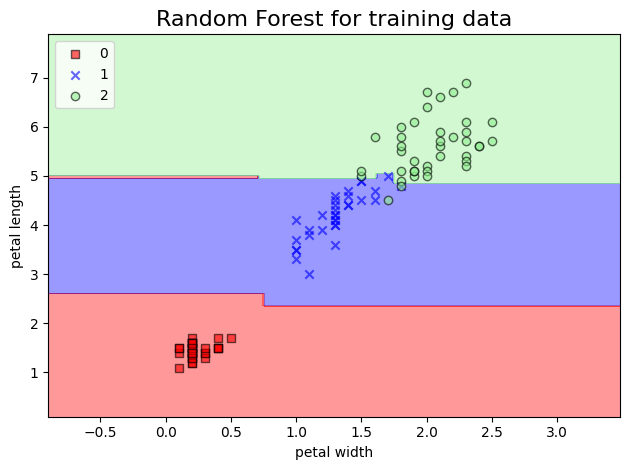

In [80]:
plot_decision_regions(X_train.values, y_train, classifier=forest)
plt.title('Random Forest for training data',fontsize=16)
plt.xlabel('petal width')
plt.ylabel('petal length')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

/Users/wuyichan/IMLP-464/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/wuyichan/IMLP-464/Unit05_2/utility.py:79: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


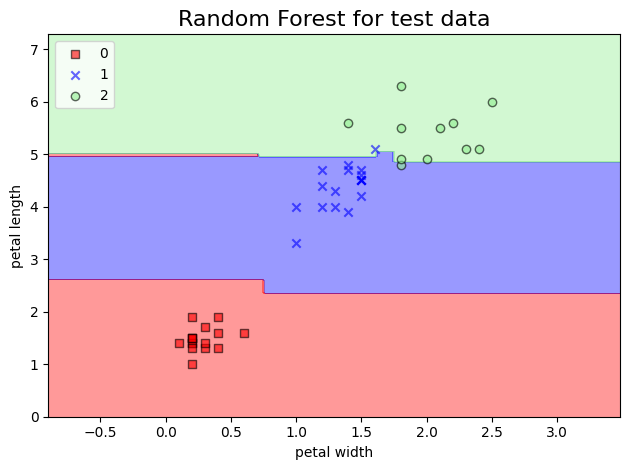

In [81]:
plot_decision_regions(X_test.values,y_test, classifier=forest)
plt.title('Random Forest for test data',fontsize=16)
plt.xlabel('petal width')
plt.ylabel('petal length')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 利用RandomForest找出Iris data 的分類主要特徵

In [82]:
forest_1 = RandomForestClassifier(criterion='entropy', n_estimators=10,random_state=0,n_jobs=8) 

iris = datasets.load_iris()
x = pd.DataFrame(iris['data'], columns=iris['feature_names'])
print("target_names: "+str(iris['target_names']))
y = pd.DataFrame(iris['target'], columns=['target'])
iris_data = pd.concat([x,y], axis=1)
#iris_data = iris_data[['sepal length (cm)','petal length (cm)','target']]
#只取 target 0,2
#iris_data = iris_data[iris_data['target'].isin([1,2])]

iris_data.head()


target_names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [83]:
X_train, X_test, y_train, y_test = train_test_split(
     iris_data.drop(['target'],axis=1), iris_data['target'], test_size=0.3, random_state=0)

In [84]:
forest_1.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [85]:
importances = forest_1.feature_importances_#現在特徵的重要性
print(importances)
indices = np.argsort(importances)  #np.argsort :Returns the indices that would sort an array. 
print(indices)#排序索引(最小開始編號)

[0.13385803 0.02750716 0.38149926 0.45713555]
[1 0 2 3]


In [86]:
features =X_train.keys()
features

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

In [87]:
features[indices]

Index(['sepal width (cm)', 'sepal length (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

Index(['sepal width (cm)', 'sepal length (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')


Text(0.5, 0, 'Relative Importance')

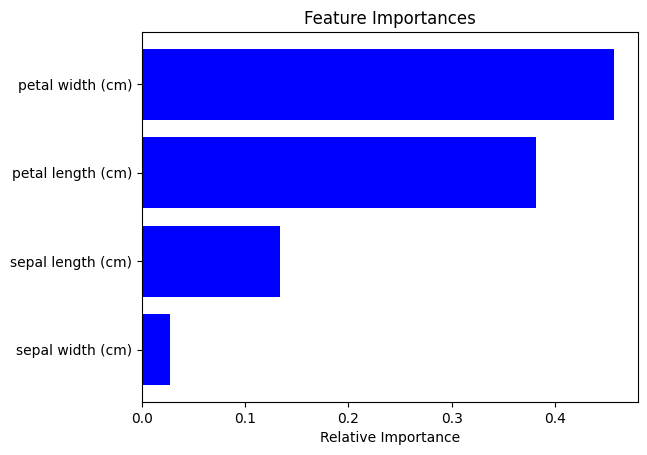

In [88]:
plt.figure(1)
print(features[indices])
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), features[indices])
plt.xlabel('Relative Importance')